# NOTEBOOK DESCRIPTION
We use the dataset published by Commission for Energy
Regulation (CER) in Ireland for the experiments. The
dataset contains load profiles of over 6000 residential consumers
and small & medium enterprises for approximately one
and a half years (from July 1, 2009 to December 31, 2010)
with a half-hourly resolution. As we are also interested in the
forecasting performance on consumer aggregates at the higher
network levels, e.g., transformer stations or feeder loads, three
additional aggregates, representing small, medium and large
transformer stations are created. To generate realistic load
aggregates from the initial pool of individual load time series, a
total of 1000 time series are created.
<br>

The goal of this notebook is to show the intuition behind sampling aggregates of data from CER dataset. We did not use regular sampling. We have first clustered the original consumers from CER dataset and than created aggregates (representing transformer stations) with different daily profiles using clustering information while sampling. The idea is to create transfomer stations with different behaviors. <br>

To generate realistic load aggregates from the initial pool of individual load time series, a total of 1000 time series corresponding to the following groups were created for the experiments, i.e.:
- Individual consumers (single): 250 time series of individual consumers;
- Small transformer stations (sTS): 250 time series each having 50 consumers in an aggregate;
- Medium transformer stations (mTS): 250 time series each having 100 consumers in an aggregate;
- Large transformer stations (lTS) 250 time series each having 200 consumers in an aggregate.


Why we do not use regular sampling (where probability of chosing each consumer in a set is the same)? <br>
If you would use regular sampling (without replacement), all the resulting aggregated time series would be very similar, thus all the time series in a particular aggregate would represent "average" behaviour. E.g. for creating 250 large transformer stations (larger transformer stations have 200 consumers) time series, we have to first randomly sample 200 consumers, aggregate the load and repeat 250x. In the end, this would result in having 250 time series, which are quite similar. It would not make sense to train a model on a 1000 time series, where time series in a set are so similar to each other. <br>

In this notebook, we only load the final created dataset that was used for experiments, whereas we do not share a code for creating aggregates. Nevertheless, the sampling procedure is as follows:<br>
1. We leverage Monte Carlo sampling to produce realistic load aggregates representing transformer stations with different daily profile behaviours (various residential and commercial areas and a mix of them). Different daily profile behaviours are first determined by clustering.<br>
2. Cluster input set of individual time series (residential & commercial) in 10 groups using KMeans, where each customer is represented with mean daily profiles of week day, Saturday and Sunday. Final results provide cluster label for each customer.<br>
3. Let $n_{samples}$ and $n_{samples\,in\,agg}$ denote number of consumers and number of samples in aggregate respectively.
For every aggregate type in our case $n_{samples} = 250$, whereas for small transformer station  $n_{samples\,in\,agg} = 50$.<br>
4. Next, let $clust_{share}$ denote share of consumers in a particular cluster group (sampled in range between 5 % and 95 %). According to $clust_{share}$, we calculate number of customers in aggregate that corresponds to particular cluster centroid. E.g. if $clust_{share}$ = 0.8 and $n_{samples\,in\,agg} = 50$, there will be 40 consumers (80 %) selected that correspond to particular cluster (every time creating one series out of 50 total series). Other 20 % of customers, will be selected randomly without replacement. In this case, that transformer station will be dominated by consumers in that particular cluster group.<br>
5. Apart from load aggregates representing transformer stations, there are also 250 individual consumers, which are sampled randomly without replacement.

# LIBS

In [15]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os

%matplotlib inline
mpl.rcParams['figure.facecolor'] = "w"

# FUNCTIONS

In [16]:
def reshape2threedays(df_in):
    """
    DESCRIPTION: Reshapes input dataframe with hourly resolution to a dataframe, 
                 where every consumer has a weekly mean profile in each row. 
    
    Input:
    df_in (pd.DataFrame): Dataframe holding time series data with hourly resolution in every column. Indices are timestamps.
    
    Output:
    df (pd.DataFrame): Dataframe holding time series data with daily resolution and hours in every columns.
    
    """
    df = df_in.copy()
    df.columns.name = "ts_id"
    df.index.name = "timestamp"
    df = df.unstack().reset_index()
    
    # 0 = weekdays, 5 = Saturday, 6 = Sunday
    dayofweek = df.timestamp.dt.dayofweek
    days = dayofweek.where(dayofweek >= 5, 0).rename("dayofweek")
    
    df = (pd.pivot_table(df, 
                         values=0, 
                         index=df.ts_id,
                         columns=[days, 
                                  df.timestamp.rename("hour").dt.hour]
                         )
            .round(3)
         )
    return df


def normalize_df(df):
    """
    DESCRIPTION: Normalizes input dataframe according to daily maximum.
    """
    # fillna is for profiles with only zeros per day
    return df.apply(lambda s: s / df.max(axis=1)).fillna(0)

    
    
def plot_clustered_profiles(df, clust, n_cols=3, alpha=0.2):
    """
    DESCRIPTION: Plots one subplot per cluster, where each subplot contains
                    all profiles in a particular cluster together with a cluster centroid.
                    Noise points (label -1, e.g. from DBSCAN) are automatically excluded.

    Input:
    df (pd.DataFrame): Normalised weekly-mean profiles (one row per consumer).
    clust (pd.Series): Cluster labels aligned to df's index.
    n_cols (int): Number of subplot columns.
    alpha (float): Transparency for individual profiles.
    """
    # Exclude noise points (label == -1, e.g. produced by DBSCAN)
    n_noise = (clust == -1).sum()
    clust = clust[clust != -1]
    df = df.loc[clust.index]

    clust_perc = 100 * clust.value_counts(normalize=True)

    n_rows = int(np.ceil(clust.nunique() / n_cols))
    fontsize = 15
    x_axis = ["Week day", "Saturdays", "Sundays"]

    fig = plt.figure(figsize=[15, n_rows*4])

    if n_noise > 0:
        fig.suptitle(f"Note: {n_noise} noise point(s) (label -1) excluded from plot",
                     fontsize=11, color="red", y=1.01)

    for i, clust_n in enumerate(clust_perc.index):

        ax = fig.add_subplot(n_rows, n_cols, i+1)
        df_plot = df[clust == clust_n]
        
        step = 10 if df_plot.shape[0] > 500 else 1  # plot less profiles

        plt.plot(df_plot.iloc[::step].T.values, alpha=alpha, color="dodgerblue")
        df_plot.mean().plot(ax=plt.gca(), alpha=1, color="k", legend=False);

        plt.title("clust: {}, perc: {:.1f}%".format(clust_n, 
                                                    clust_perc.loc[clust_n]), 
                                                    fontsize=fontsize+5);
        plt.xticks(np.arange(0, 72, 24), x_axis, fontsize=12);
        plt.yticks(np.arange(0, 1.1, 0.1), fontsize=fontsize);

        plt.xlabel("Hours", fontsize=fontsize)
        plt.ylabel("$P/P_{max}$", fontsize=fontsize)
        plt.grid()
        plt.ylim(0, 1)

    plt.tight_layout()


# 0. INPUT DATA

In [17]:
# DATA PATH
base_dir = os.getcwd()
csv_path = os.path.join(base_dir, "Ausgrid_2010_2013_Orange_Combined.csv")

# LOAD LONG-FORMAT AUSGRID DATA
raw = pd.read_csv(
    csv_path,
    usecols=["Timestamp_UTC", "UserID", "Energy_Consumption"],
)
raw["Timestamp_UTC"] = pd.to_datetime(raw["Timestamp_UTC"], utc=True).dt.tz_localize(None)

# KEEP ONLY 300 USERS
n_users = 300
selected_users = np.sort(raw["UserID"].dropna().unique())[:n_users]
if selected_users.size < n_users:
    raise ValueError(f"Requested {n_users} users, but dataset has only {selected_users.size} users.")

raw = raw[raw["UserID"].isin(selected_users)]

# PIVOT TO WIDE FORMAT (timestamp index, one column per user)
data = (
    raw.pivot_table(
        index="Timestamp_UTC",
        columns="UserID",
        values="Energy_Consumption",
        aggfunc="mean",
    )
    .sort_index()
    .astype(np.float32)
    .fillna(0.0)
)
data.columns = [f"user_{int(c)}" for c in data.columns]

print(f"Using {data.shape[1]} users and {data.shape[0]} timestamps from {os.path.basename(csv_path)}")

Using 300 users and 52608 timestamps from Ausgrid_2010_2013_Orange_Combined.csv


The original Ausgrid file is in long format (`Timestamp_UTC`, `UserID`, `Energy_Consumption`). We pivot it into DataFrame `data` with timestamps as index and one column per user, and then keep 300 users for clustering experiments.

In [18]:
data.shape

(52608, 300)

In [19]:
data.head()

,user_1,user_2,user_3,user_4,user_5,user_6,user_7,user_8,user_9,user_10,...,user_291,user_292,user_293,user_294,user_295,user_296,user_297,user_298,user_299,user_300
Timestamp_UTC,,,,,,,,,,,,,,,,,,,,,
2010-07-01 00:30:00,0.303,0.085,0.669,0.075,0.0,0.044,0.093,0.124,0.033,0.031,...,0.398,0.044,0.006,0.102,0.059,0.019,0.205,0.096,1.464,0.279
2010-07-01 01:00:00,0.471,0.142,0.671,0.086,0.0,0.041,0.100,0.088,0.019,0.051,...,0.413,0.056,0.000,0.203,0.062,0.048,0.106,0.110,1.413,0.924
2010-07-01 01:30:00,0.083,0.082,0.675,0.085,0.0,0.047,0.090,0.150,0.008,0.052,...,0.276,0.588,0.009,0.236,0.037,0.030,0.169,0.080,1.428,0.803
2010-07-01 02:00:00,0.121,0.119,0.683,0.084,0.0,0.046,0.051,0.097,0.009,0.043,...,0.307,0.069,0.000,0.160,0.081,0.019,0.270,0.105,1.445,0.066
2010-07-01 02:30:00,0.361,0.105,0.694,0.084,0.0,0.047,0.148,0.115,0.009,0.026,...,0.264,0.031,0.008,0.176,0.041,0.018,0.255,0.089,1.407,0.089


# 1. CLUSTERING CREATED TIME SERIES USING KMeans
In order to show the importance of creating aggregate types with different behaviours (instead of using simple random sampling), we cluster the resulting time series.

In [20]:
X_weekly_mean = reshape2threedays(data.resample("1h").mean())

X_weekly_mean_norm = normalize_df(X_weekly_mean)
print("X_weekly_mean_norm shape:", X_weekly_mean.shape)

n_clusters = 20
model = KMeans(n_clusters).fit(X_weekly_mean_norm.values)
clust = pd.Series(model.labels_, index=X_weekly_mean_norm.index)

X_weekly_mean_norm shape: (300, 72)


As you can see below, time series in a dataset have different daily behaviours.

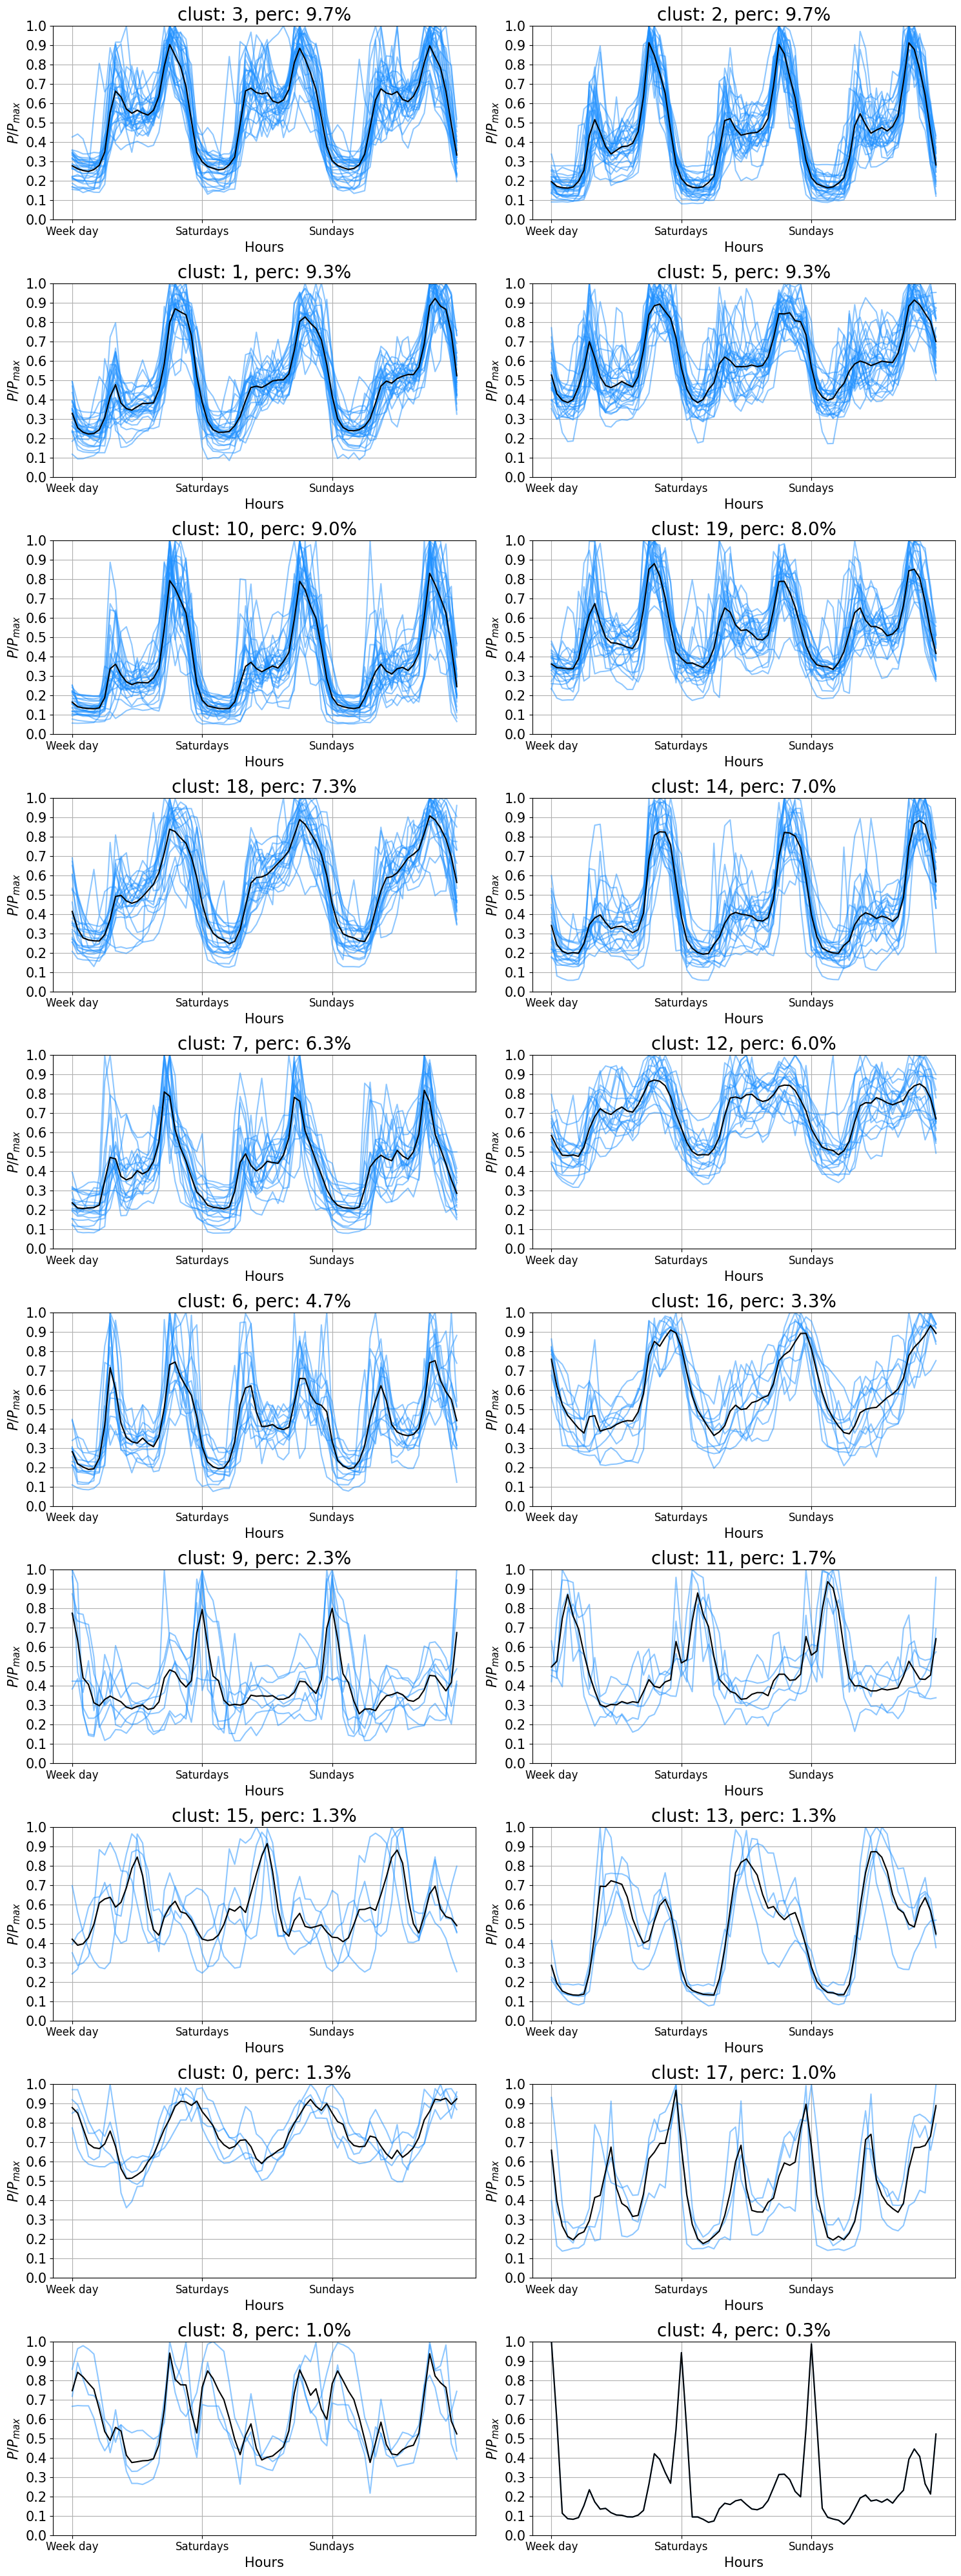

In [21]:
plot_clustered_profiles(X_weekly_mean_norm, clust, n_cols=2, alpha=0.5);

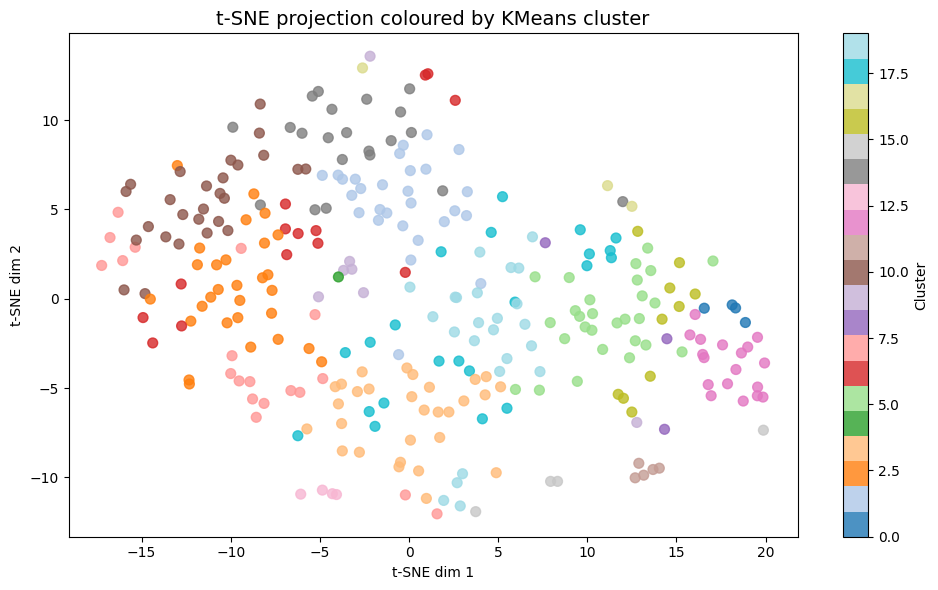

In [22]:
from sklearn.manifold import TSNE

# Compute t-SNE 2D projection of normalised weekly profiles
tsne_results = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_weekly_mean_norm.values)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    tsne_results[:, 0], tsne_results[:, 1],
    c=clust.values, cmap="tab20", alpha=0.8, s=50
)
plt.colorbar(sc, ax=ax, label="Cluster")
ax.set_title("t-SNE projection coloured by KMeans cluster", fontsize=14)
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()

# 4. CLUSTERING CREATED TIME SERIES USING Hierarchical Clustering (Agglomerative)


In [23]:
from sklearn.cluster import AgglomerativeClustering

# Linkage determines how distance between clusters is measured
model_agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward').fit(X_weekly_mean_norm.values)
agglo_labels = model_agglo.labels_


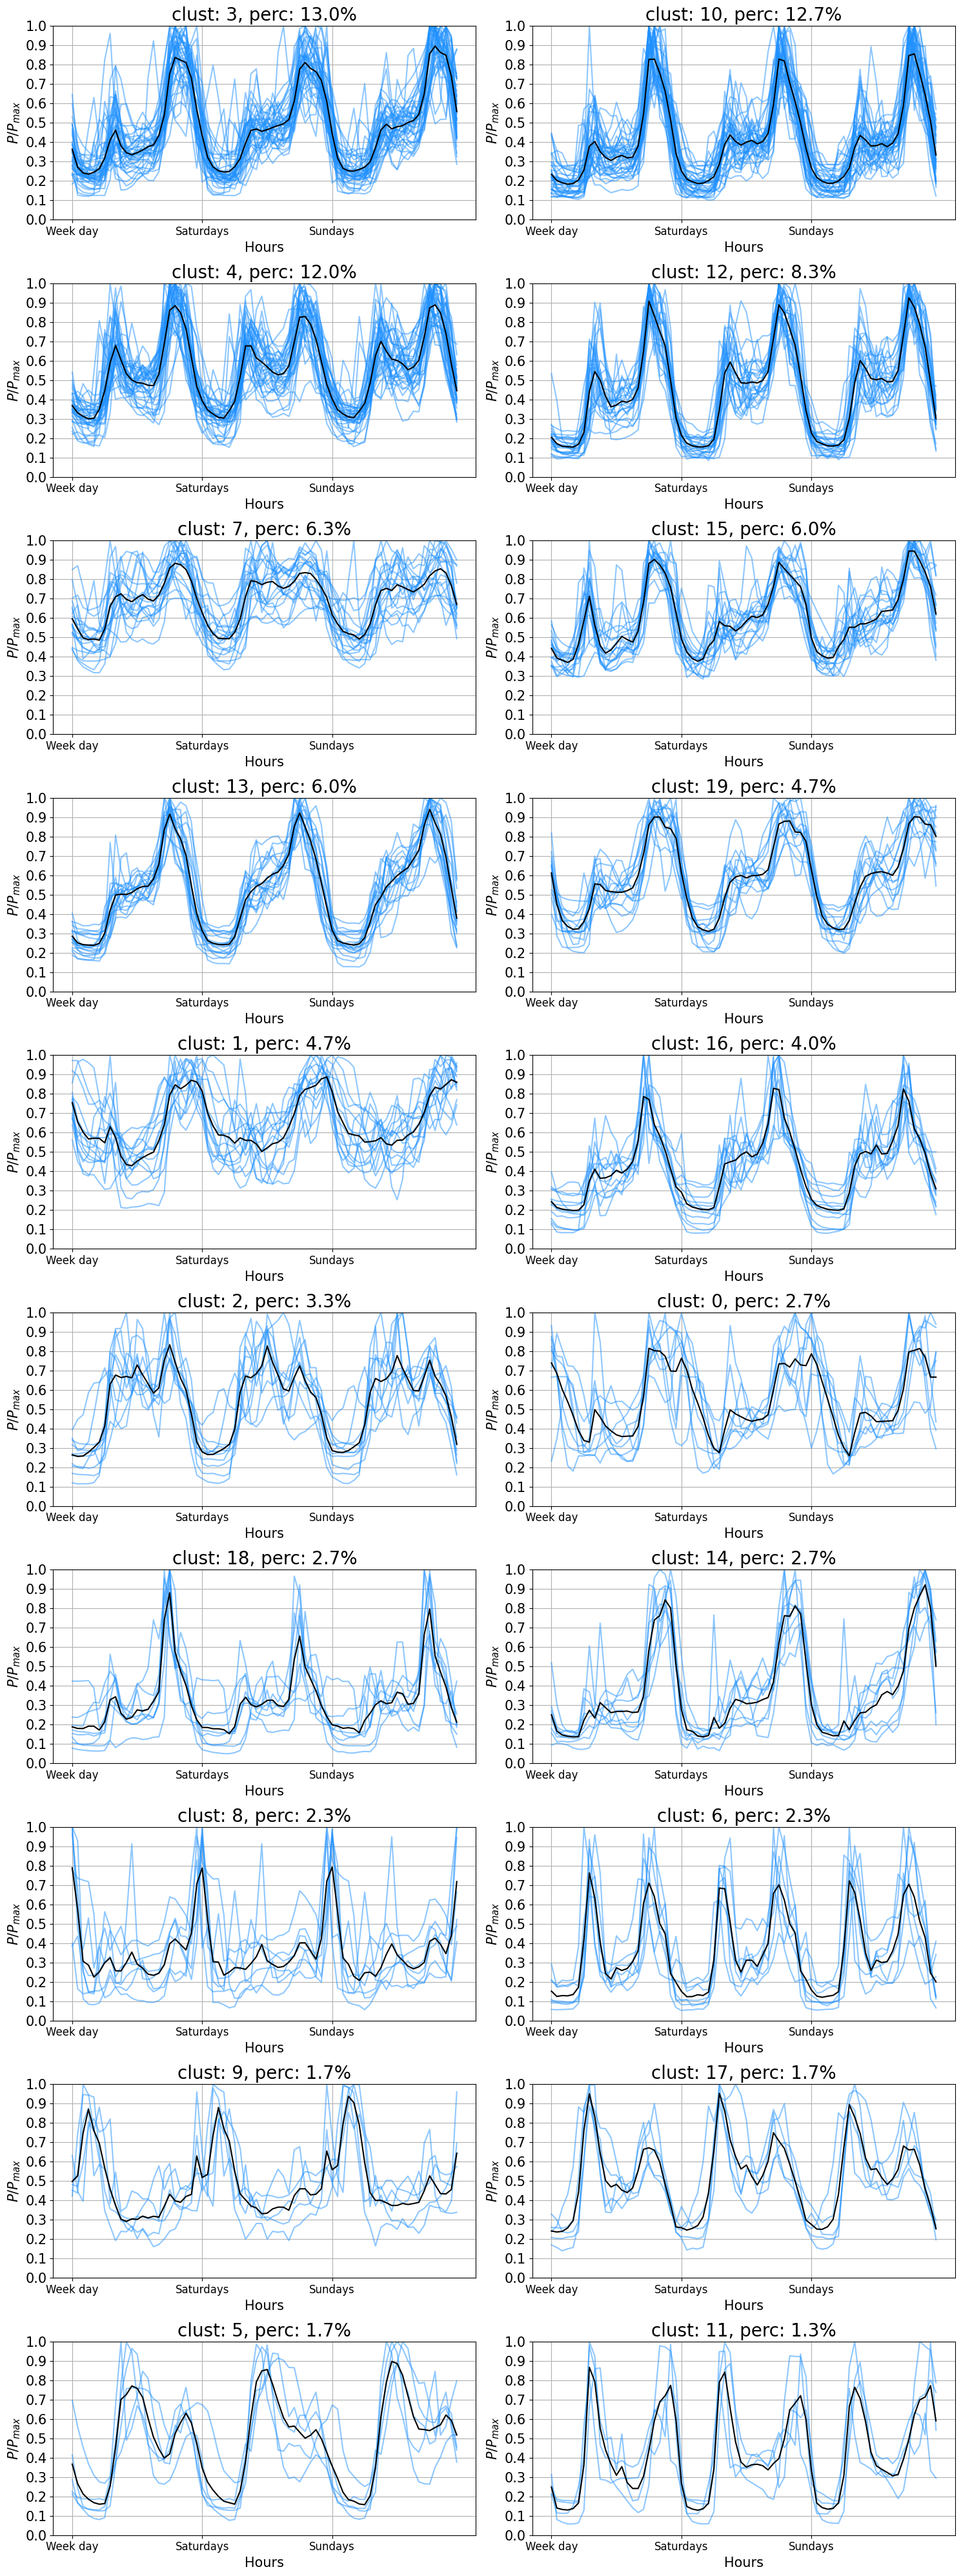

In [24]:
clust_agglo = pd.Series(agglo_labels, index=X_weekly_mean_norm.index)
plot_clustered_profiles(X_weekly_mean_norm, clust_agglo, n_cols=2, alpha=0.5)


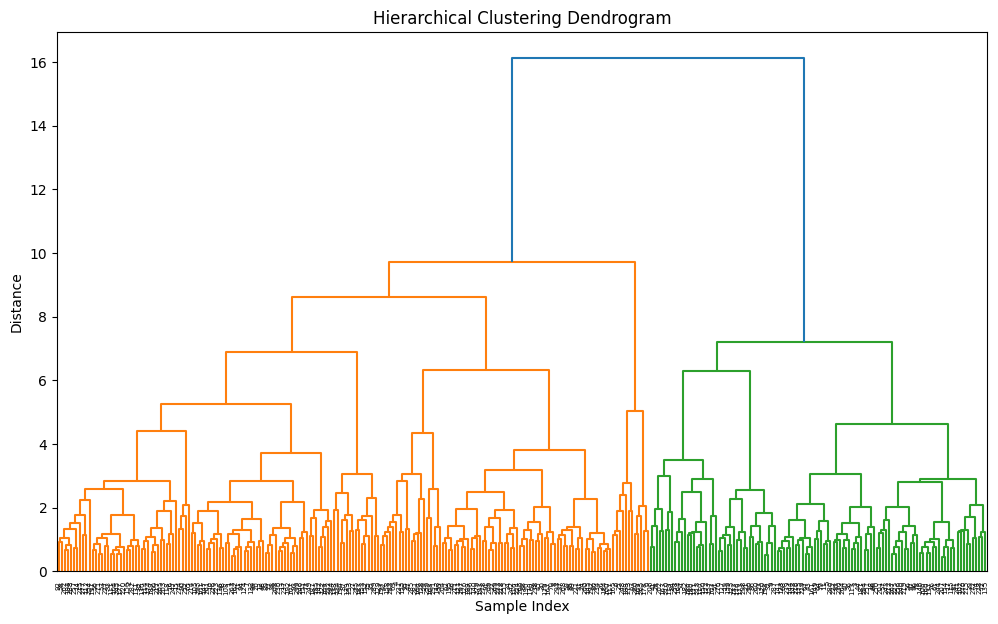

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Calculate the linkage matrix
linked = linkage(X_weekly_mean_norm.values, 'ward')

plt.figure(figsize=(12, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# 5. CLUSTERING CREATED TIME SERIES USING GMM


In [26]:
from sklearn.mixture import GaussianMixture

# covariance_type 'full' allows for elliptical clusters
model_gmm = GaussianMixture(n_components=n_clusters, covariance_type='full').fit(X_weekly_mean_norm.values)

# You can get the hard labels or the probabilities
gmm_labels = model_gmm.predict(X_weekly_mean_norm.values)
probs = model_gmm.predict_proba(X_weekly_mean_norm.values)


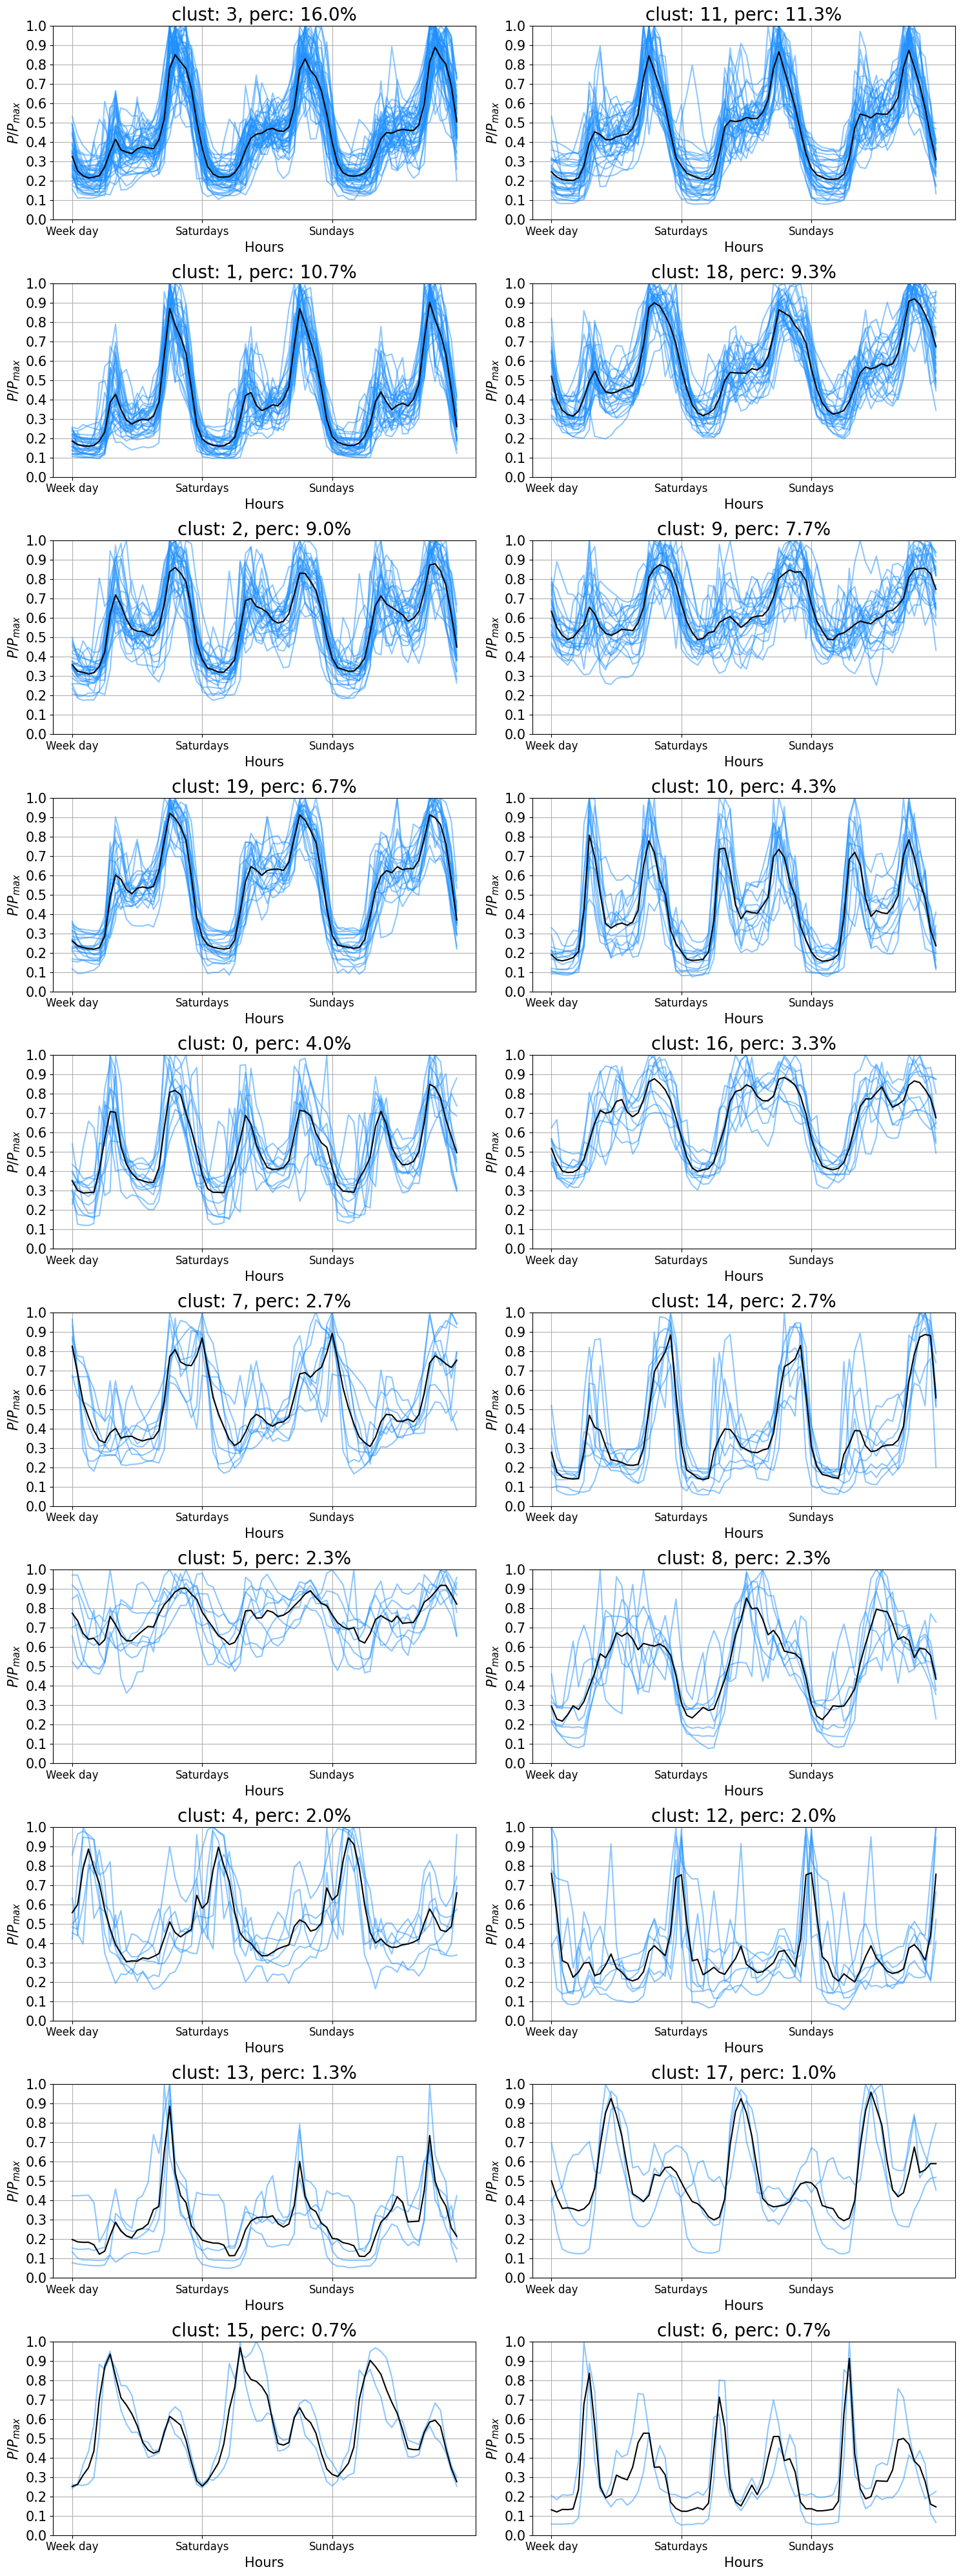

In [27]:
clust_gmm = pd.Series(gmm_labels, index=X_weekly_mean_norm.index)
plot_clustered_profiles(X_weekly_mean_norm, clust_gmm, n_cols=2, alpha=0.5)


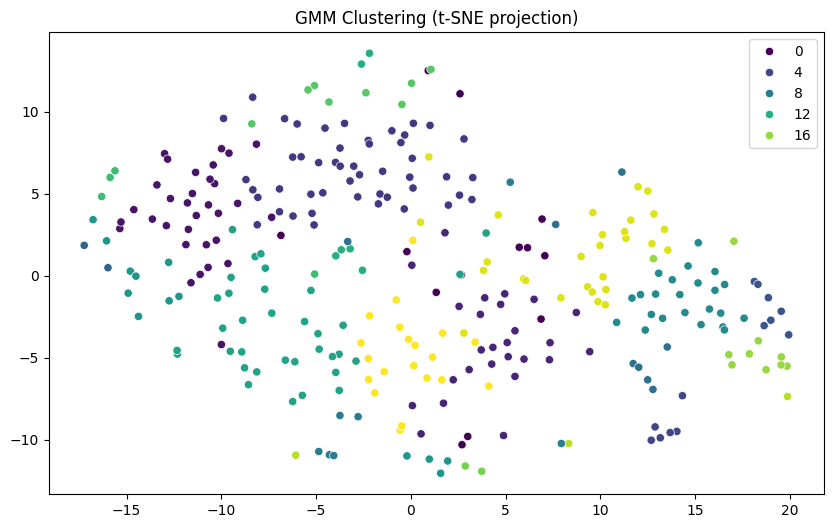

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you've already run .fit() and have 'gmm_labels'
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=gmm_labels, palette='viridis')
plt.title('GMM Clustering (t-SNE projection)')
plt.show()


# 11. Chosen Clustering Method: Agglomerative (Ward)

## Comparison summary

Four clustering approaches were evaluated on the same normalised weekly-mean profiles (weekday / Saturday / Sunday, hourly resolution):

| Method | Avg RMSE | Silhouette | Calinski-Harabasz | Davies-Bouldin | **Avg rank** |
|---|---|---|---|---|---|
| **Agglomerative** | 0.1038 | 0.0826 | 23.55 | 1.845 | **1.8** |
| KMeans | 0.1043 | 0.0715 | 23.07 | 1.833 | 2.6 |
| GMM | 0.1047 | 0.0824 | 22.82 | 1.757 | 2.8 |
| DBSCAN (tuned) | 0.1543 | 0.3631 | 12.62 | 0.905 | 2.8 |

> Ranks: lower RMSE/MSE/Davies-Bouldin → rank 1; higher Silhouette/Calinski-Harabasz → rank 1. Average rank computed across all five criteria.

## Why Agglomerative Clustering?

**Agglomerative Clustering with Ward linkage** achieves the best overall average rank (1.8) across the five evaluation criteria:

- **Lowest centroid error** – mean RMSE 0.1038, meaning consumers fit most tightly inside their assigned cluster.
- **Highest Calinski-Harabasz score** (23.55) – clusters are dense and well-separated relative to one another.
- **No noise** – unlike DBSCAN, every consumer is assigned to a cluster; no data is discarded as noise.
- **Deterministic** – Ward linkage produces the same result every run, unlike KMeans (random initialisation) or GMM (EM optimisation).
- **Interpretable hierarchy** – the dendrogram (section 4) reveals the natural merge order of groups, which is useful for understanding consumer segments.

KMeans and GMM are close second and third (average ranks 2.6 and 2.8) but less stable across runs. DBSCAN collapses 300 consumers into 2 clusters while discarding 14 as noise — it is not suitable for this task without a very different parameter regime.

**Conclusion: Agglomerative Clustering with Ward linkage and 20 clusters is the recommended method.**

In [29]:
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering

# Re-run Agglomerative clustering (winner) on normalised weekly profiles
n_clusters = 20
model_final = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward').fit(X_weekly_mean_norm.values)
clust_final = pd.Series(model_final.labels_, index=X_weekly_mean_norm.index, name="cluster")

# Compute Euclidean distance from each user to their cluster centroid
X = X_weekly_mean_norm.to_numpy(dtype=float)
centroids = np.array([
    X[clust_final.values == c].mean(axis=0)
    for c in range(n_clusters)
])
dist_to_centroid = np.linalg.norm(X - centroids[clust_final.values], axis=1)

ranking_df = pd.DataFrame({
    "user_id":          X_weekly_mean_norm.index,
    "cluster":          clust_final.values,
    "dist_to_centroid": dist_to_centroid,
})

# Sort by cluster, then by distance ascending (rank 1 = closest to centroid = best fit)
ranking_df = ranking_df.sort_values(["cluster", "dist_to_centroid"]).reset_index(drop=True)
ranking_df["rank_in_cluster"] = ranking_df.groupby("cluster").cumcount() + 1

display(ranking_df.head(20))

# Write sorted user IDs to file
out_path = os.path.join(base_dir, "user_ids_sorted_by_cluster.csv")
ranking_df.to_csv(out_path, index=False)
print(f"Saved {len(ranking_df)} rows → {out_path}")

,user_id,cluster,dist_to_centroid,rank_in_cluster
0,user_246,0,0.836041,1
1,user_285,0,0.988724,2
2,user_136,0,1.050720,3
3,user_206,0,1.053159,4
4,user_289,0,1.152030,5
5,user_281,0,1.158519,6
6,user_124,0,1.273868,7
7,user_175,0,1.699976,8
8,user_234,1,0.602957,1
9,user_291,1,0.748871,2


Saved 300 rows → /Users/tomaz/Documents/Andraz/Household-RL/user_ids_sorted_by_cluster.csv
